### ⛹️‍♂️ Body Performance - PCA & t-SNE

# ℹ️ About Dataset 

This is data that confirmed the grade of performance with age and some exercise performance data.

Link : https://www.kaggle.com/datasets/kukuroo3/body-performance-data

# 🔑 Key Features 

* **age** : 20 ~64
* **gender** : F,M
* **height_cm** : (If you want to convert to feet, divide by 30.48)
* **weight_kg**
* **body fat_%**
* **diastolic** : diastolic blood pressure (min)
* **systolic** : systolic blood pressure (min)
* **gripForce**
* **sit and bend forward_cm**
* **sit-ups counts**
* **broad jump_cm**
* **class** : A,B,C,D ( A: best) / stratified

# Source

link (Korea Sports Promotion Foundation)
Some post-processing and filtering has done from the raw data.

In [246]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score , recall_score , f1_score ,accuracy_score
from sklearn.metrics import RocCurveDisplay

# Load Data

In [247]:
data = pd.read_csv(r'C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab5_PCA_TSNE\dataset\bodyPerformance.csv')
data = data.sample(frac=1).reset_index(drop=True)
data = data[:3000]
data.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,48.0,F,158.0,48.00,25.6,64.0,108.0,21.8,20.0,23.0,130.0,B
1,26.0,M,169.4,71.20,18.4,72.0,140.0,42.9,15.1,52.0,237.0,A
2,27.0,F,164.0,51.00,20.4,75.0,122.0,25.3,19.4,36.0,163.0,A
3,25.0,F,169.2,53.10,22.3,66.0,123.0,26.3,14.2,40.0,162.0,B
4,29.0,M,171.8,67.16,21.7,78.0,120.0,32.7,13.2,35.0,200.0,D


In [248]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3000 non-null   float64
 1   gender                   3000 non-null   object 
 2   height_cm                3000 non-null   float64
 3   weight_kg                3000 non-null   float64
 4   body fat_%               3000 non-null   float64
 5   diastolic                3000 non-null   float64
 6   systolic                 3000 non-null   float64
 7   gripForce                3000 non-null   float64
 8   sit and bend forward_cm  3000 non-null   float64
 9   sit-ups counts           3000 non-null   float64
 10  broad jump_cm            3000 non-null   float64
 11  class                    3000 non-null   object 
dtypes: float64(10), object(2)
memory usage: 281.4+ KB


In [249]:
# Check for null data
data.isnull().sum() 

age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

In [250]:
# Select columns with data type 'object'
for col in data.columns :
    if data[col].dtypes == 'object' : 
        print(col)

gender
class


In [251]:
# Create encoding for object cols 
unique_gender = np.unique(data['gender'])
data['gender'] = [ ((g == unique_gender).astype(int)).argmax() for g in data['gender']]
unique_class = np.unique(data['class'])
data['class'] = [ ((c == unique_class).astype(int)).argmax() for c in data['class']]
data.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,48.0,0,158.0,48.00,25.6,64.0,108.0,21.8,20.0,23.0,130.0,1
1,26.0,1,169.4,71.20,18.4,72.0,140.0,42.9,15.1,52.0,237.0,0
2,27.0,0,164.0,51.00,20.4,75.0,122.0,25.3,19.4,36.0,163.0,0
3,25.0,0,169.2,53.10,22.3,66.0,123.0,26.3,14.2,40.0,162.0,1
4,29.0,1,171.8,67.16,21.7,78.0,120.0,32.7,13.2,35.0,200.0,3


In [252]:
data_class = data['class'].value_counts().sort_index()
data_class

class
0    738
1    771
2    724
3    767
Name: count, dtype: int64

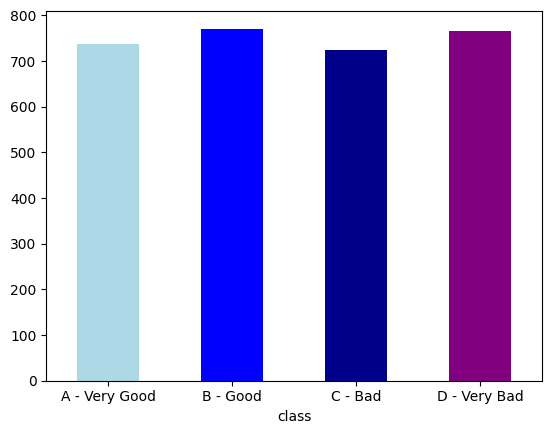

In [253]:
data_class.plot(kind='bar' , color=['lightblue','blue','darkblue','purple','black'])
plt.xticks(ticks=[0,1,2,3] , rotation=0 , labels=['A - Very Good' , 'B - Good' , 'C - Bad' , 'D - Very Bad'])
plt.show()

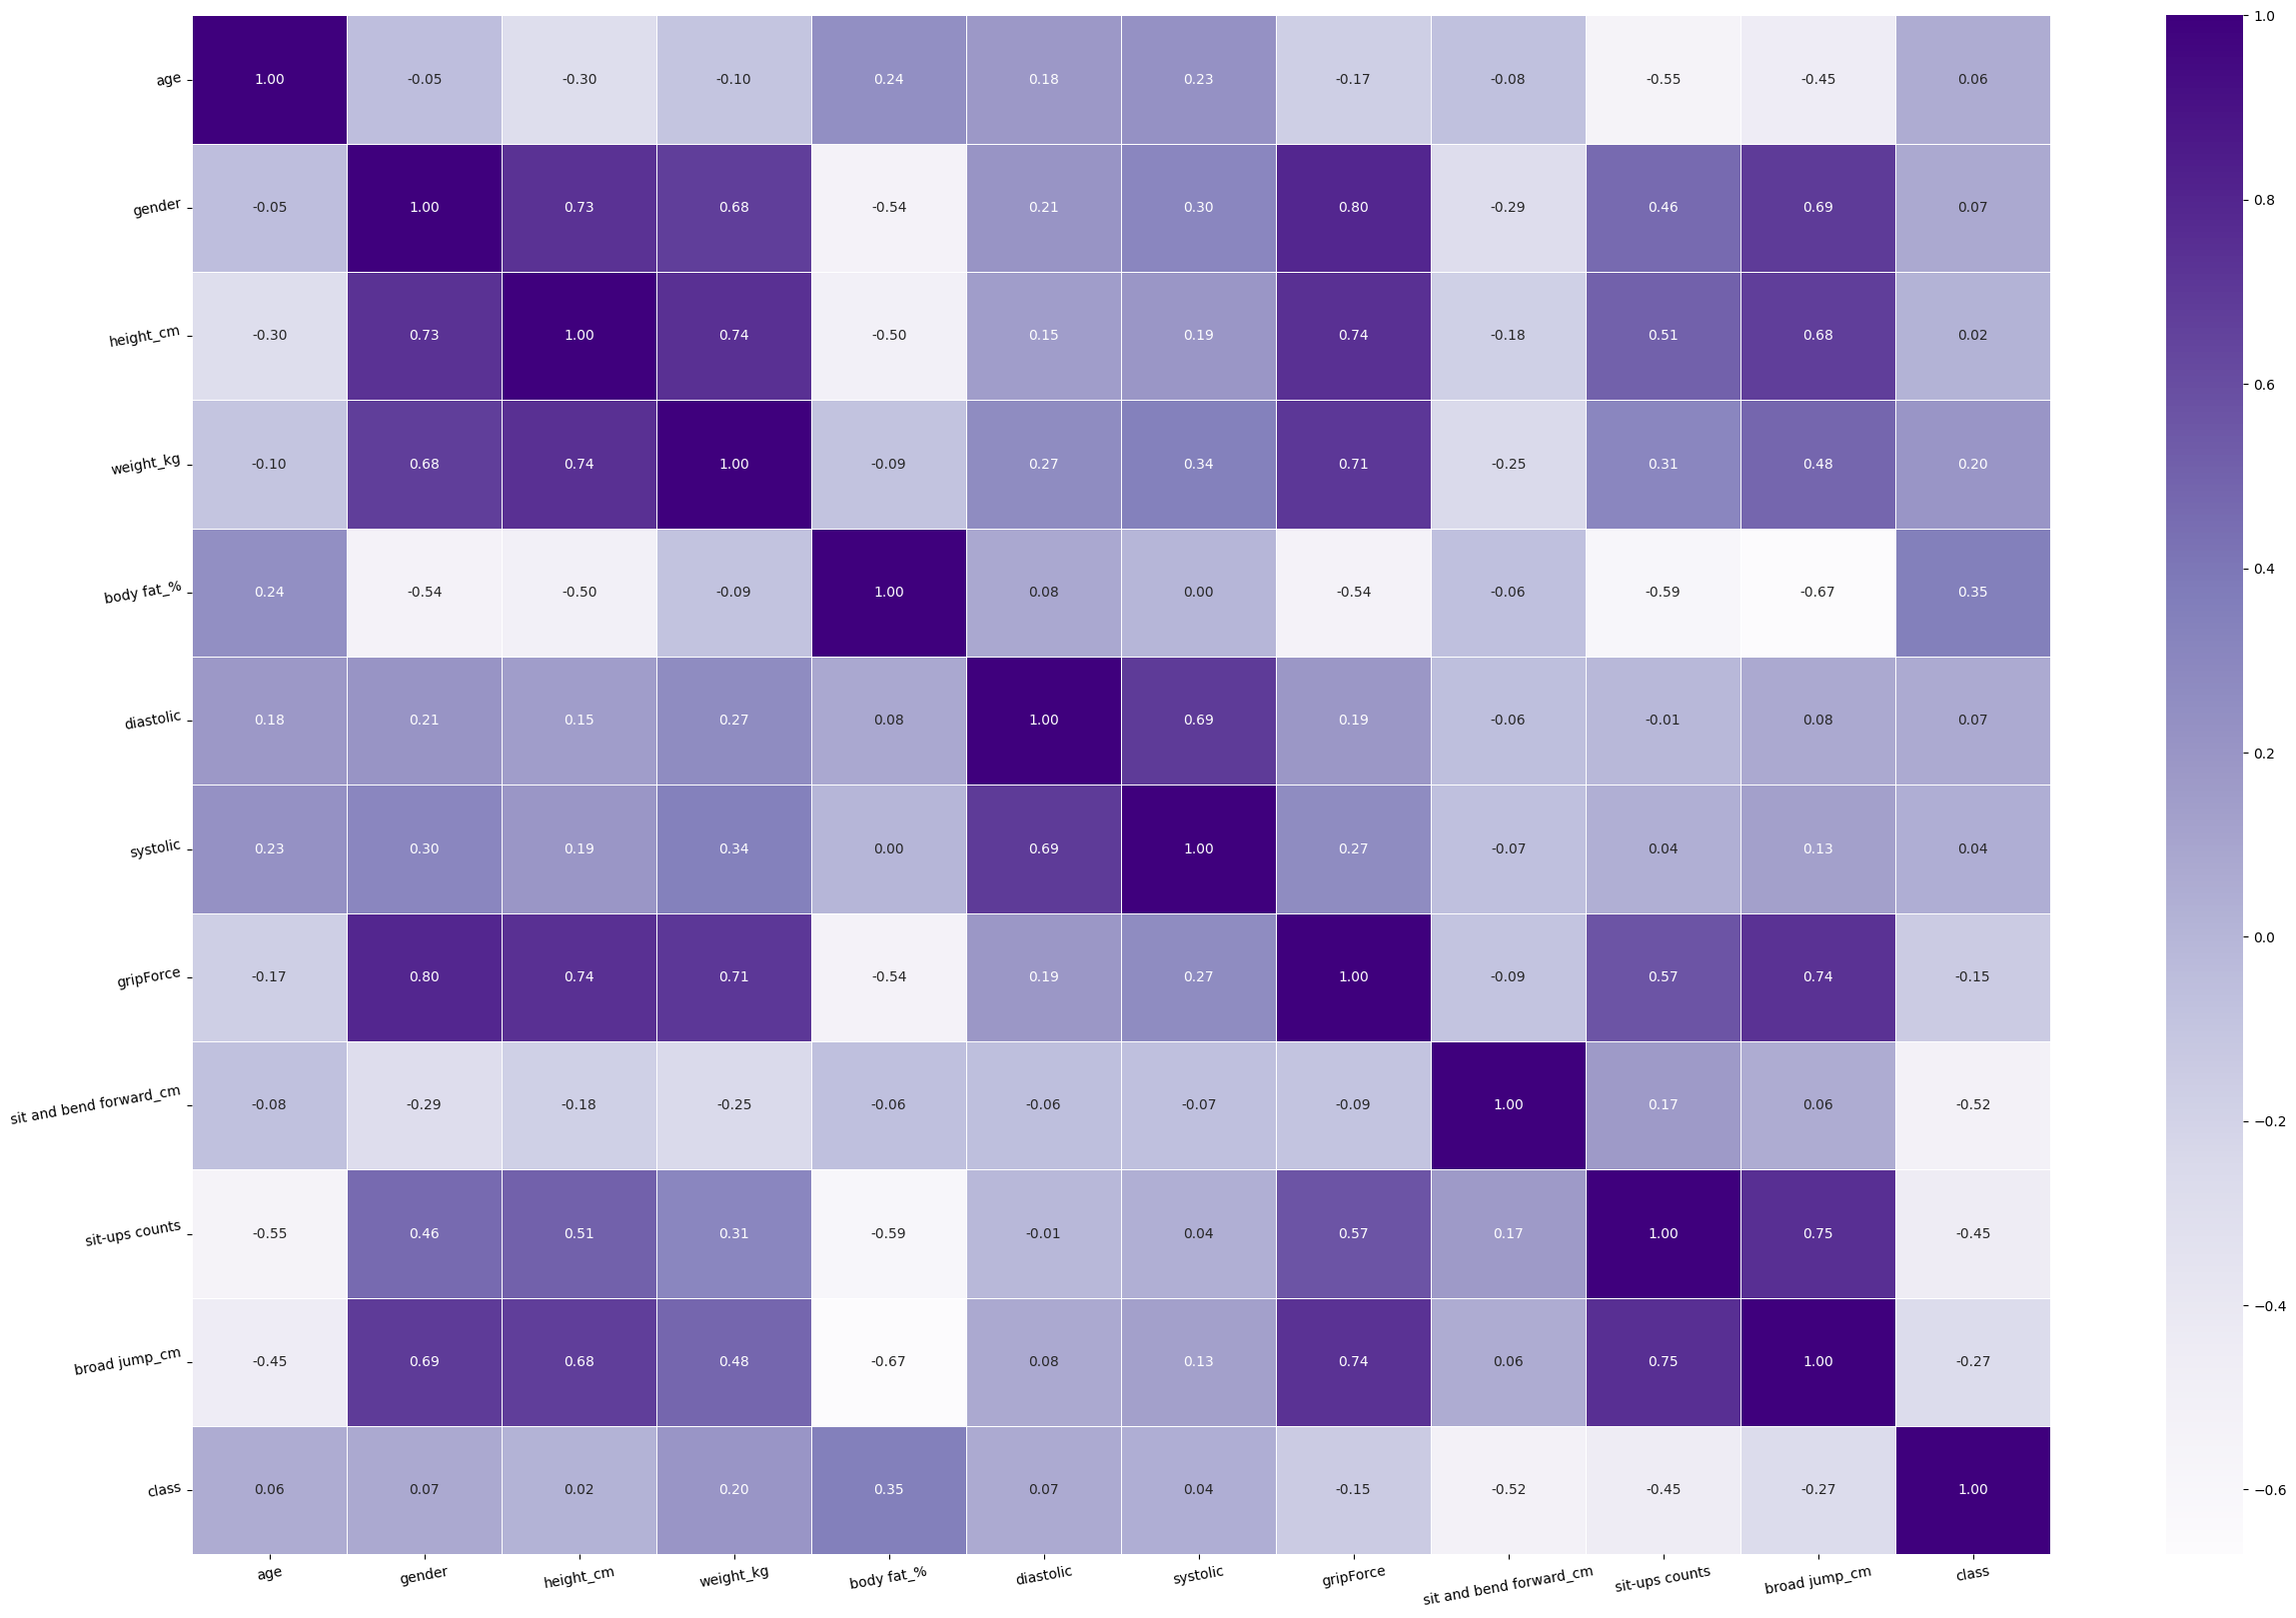

In [254]:
# Corelation Matrix 
corr_matrix = data.corr()
fix,ax = plt.subplots(figsize=(30,20))
ax = sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , fmt='.2f' , cmap='Purples');
plt.xticks(rotation=10)
plt.yticks(rotation=10)
plt.show()

### Create X & y and split the data

In [255]:
X = data.drop('class' , axis=1)
y = data['class']

In [256]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(2400, 2400, 600, 600)

In [257]:
# Preprocessing data - standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)

In [258]:
# Import PCA & t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# SVC without PCA

In [259]:
from sklearn.svm import SVC
import time 

svc = SVC(kernel='rbf' , C=1.0 , gamma='scale' , random_state=42)
svc_without_pca_score = {}

start_time = time.time()
svc.fit(X_train_scaled , y_train)
end_time = time.time() - start_time

score = svc.score(X_train_scaled , y_train)

print(f'Train time : {end_time*1000:.2f} ms')
print(f'Train Score : {score*100:.1f}%')

svc_without_pca_score['train_time'] = round(end_time * 1000 , 2)
svc_without_pca_score['train_score'] = round(score*100 , 2)

svc_without_pca_score[0] = {
     'components_number'  : 0,
     'train_time' : round(end_time * 1000 , 2),
     'acc_score' : round(score*100 , 2)
}

Train time : 106.12 ms
Train Score : 69.5%


In [260]:
y_pred = svc.predict(X_test_scaled)
print(classification_report(y_test , y_pred))
svc_without_pca = accuracy_score(y_test , y_pred)
svc_with_pca_results['acc_score'] = round(svc_without_pca * 100 , 2)

              precision    recall  f1-score   support

           0       0.70      0.74      0.72       157
           1       0.49      0.50      0.49       157
           2       0.54      0.49      0.51       134
           3       0.79      0.80      0.80       152

    accuracy                           0.64       600
   macro avg       0.63      0.63      0.63       600
weighted avg       0.63      0.64      0.63       600



# SVC with PCA

In [261]:
svc_with_pca_results = {}
def svc_with_pca(n_comp) : 
    global svc_with_pca_results
    
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    start_time = time.time()
    svc.fit(X_train_pca , y_train)
    end_time = time.time() - start_time
    
    score = svc.score(X_train_pca , y_train)
    
    print(f'Train time : {end_time*1000:.2f} ms')
    print(f'Train Score : {score*100:.1f}%')
    
    y_pred = svc.predict(X_test_pca)
    print(classification_report(y_test , y_pred))
    svc_with_pca = accuracy_score(y_test , y_pred)

    svc_with_pca_results[n_comp] = {
        'components_number' : n_comp,
        'train_time' : round(end_time*1000 , 2),
        'acc_score' : round(svc_with_pca * 100 , 2)
    }

In [262]:
svc_with_pca(2)

Train time : 121.43 ms
Train Score : 41.0%
              precision    recall  f1-score   support

           0       0.49      0.42      0.45       157
           1       0.33      0.18      0.24       157
           2       0.30      0.29      0.30       134
           3       0.42      0.69      0.53       152

    accuracy                           0.40       600
   macro avg       0.39      0.40      0.38       600
weighted avg       0.39      0.40      0.38       600



In [263]:
svc_with_pca(6)

Train time : 88.61 ms
Train Score : 62.8%
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       157
           1       0.46      0.51      0.48       157
           2       0.53      0.43      0.47       134
           3       0.77      0.80      0.79       152

    accuracy                           0.62       600
   macro avg       0.61      0.61      0.61       600
weighted avg       0.61      0.62      0.61       600



In [264]:
svc_with_pca(10)

Train time : 107.00 ms
Train Score : 69.8%
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       157
           1       0.49      0.50      0.49       157
           2       0.55      0.52      0.54       134
           3       0.81      0.79      0.80       152

    accuracy                           0.64       600
   macro avg       0.63      0.63      0.63       600
weighted avg       0.64      0.64      0.64       600



# SVC with t-SNE

In [265]:
svc_with_tsne_score = {}
def svc_with_tsne(n_comp) :
    global svc_with_tsne_score
    
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_scaled)
    X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.2, random_state=42)
    
    start_time = time.time()
    svc.fit(X_train_tsne , y_train_tsne)
    end_time = time.time() - start_time
    
    score = svc.score(X_train_tsne , y_train_tsne)
    
    print(f'Train time : {end_time*1000:.2f} ms')
    print(f'Train Score : {score*100:.1f}%')

    y_pred = svc.predict(X_test_tsne)
    print(classification_report(y_test_tsne , y_pred))
    svc_with_tsne = accuracy_score(y_test_tsne , y_pred)

    svc_with_tsne_score[n_comp] = {
          'components_number' : n_comp,
          'train_time' : round(end_time * 1000 , 2),
          'acc_score' : round(svc_with_tsne * 100 , 2)
    }

In [266]:
svc_with_tsne(2)

Train time : 146.10 ms
Train Score : 44.0%
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       157
           1       0.29      0.17      0.21       157
           2       0.29      0.18      0.22       134
           3       0.43      0.79      0.56       152

    accuracy                           0.42       600
   macro avg       0.39      0.41      0.38       600
weighted avg       0.39      0.42      0.38       600



In [267]:
svc_with_tsne(6)

Train time : 187.27 ms
Train Score : 44.0%
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       157
           1       0.29      0.17      0.21       157
           2       0.29      0.18      0.22       134
           3       0.43      0.79      0.56       152

    accuracy                           0.42       600
   macro avg       0.39      0.41      0.38       600
weighted avg       0.39      0.42      0.38       600



In [268]:
svc_with_tsne(10)

Train time : 178.45 ms
Train Score : 44.0%
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       157
           1       0.29      0.17      0.21       157
           2       0.29      0.18      0.22       134
           3       0.43      0.79      0.56       152

    accuracy                           0.42       600
   macro avg       0.39      0.41      0.38       600
weighted avg       0.39      0.42      0.38       600



In [303]:
total_scores = {}

total_scores['SVC Without PCA'] = svc_without_pca_score[0]
total_scores['SVC With PCA - N_Comp 2'] = svc_with_pca_results[2]
total_scores['SVC With PCA - N_Comp 6'] = svc_with_pca_results[6]
total_scores['SVC With PCA - N_Comp 10'] = svc_with_pca_results[10]
total_scores['SVC With TSNE - N_Comp 2'] = svc_with_tsne_score[2]
total_scores['SVC With TSNE - N_Comp 6'] = svc_with_tsne_score[6]
total_scores['SVC With TSNE - N_Comp 10'] = svc_with_tsne_score[10]

scores = pd.DataFrame(total_scores)

def highlight_col(col):
    return ['background-color: #FFFF00' for _ in col] if col.name == 'SVC Without PCA' else ['' for _ in col]

In [305]:
scores.T.style.apply(highlight_col , axis=1)

,components_number,train_time,acc_score
SVC Without PCA,0.000000,106.120000,69.460000
SVC With PCA - N_Comp 2,2.000000,121.430000,39.830000
SVC With PCA - N_Comp 6,6.000000,88.610000,61.670000
SVC With PCA - N_Comp 10,10.000000,107.000000,63.670000
SVC With TSNE - N_Comp 2,2.000000,146.100000,41.830000
SVC With TSNE - N_Comp 6,6.000000,187.270000,41.830000
SVC With TSNE - N_Comp 10,10.000000,178.450000,41.830000
